## 📝 Ridge / Lasso / ElasticNet 
---
### Yaşam Kalitesi ve Ölüm Yaşı Tahmini: Düzenlileştirilmiş Regresyon (Ridge, Lasso, ElasticNet) Projesi

Bu projede, bireylerin günlük yaşam alışkanlıkları (uyku, çalışma, dinlenme, egzersiz), cinsiyet ve meslek grupları üzerinden yaşam süresini (ölüm yaşı) tahmin eden modeller geliştirilmiştir. Geleneksel Doğrusal Regresyon'un aşırı öğrenme (overfitting) ve çoklu bağlantı (multicollinearity) risklerini en aza indirmek için **Ridge (L2)**, **Lasso (L1)** ve **ElasticNet (L1 + L2)** düzenlileştirme (regularization) teknikleri uygulanmış ve GridSearchCV ile optimize edilmiştir.

**Değişken Sözlüğü:**

* **gender:** Cinsiyet
* **occupation_type:** 14 kategorili meslek grubu
* **avg_work_hours_per_day:** Günlük çalışma süresi (saat)
* **avg_rest_hours_per_day:** Günlük dinlenme süresi (saat)
* **avg_sleep_hours_per_day:** Günlük uyku süresi (saat)
* **avg_exercise_hours_per_day:** Günlük egzersiz süresi (saat)
* **age_at_death (Hedef Değişken):** Ölüm yaşı

In [2]:
# =============================================================================
# 1. KÜTÜPHANE İÇE AKTARIMLARI VE AYARLAR
# =============================================================================

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

# Görselleştirme Ayarları
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures , StandardScaler 
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error , mean_squared_error
from sklearn.pipeline import Pipeline

from sklearn.linear_model import  Ridge , ElasticNet , Lasso 

import warnings
warnings.filterwarnings("ignore")

## 📝 Veri Yükleme ve Keşif
---
### 2. Veri Yükleme & İlk İnceleme
Veri setimizi yüklüyor ve hedef değişkenimiz olan "Ölüm Yaşı"nın (age_at_death) dağılımını inceliyoruz. Modelin performansını olumsuz etkilememesi adına anlamsız olan id kolonunu veriden çıkarıyoruz.

In [3]:
df = pd.read_csv("Updated Quality of Life Data.csv")

In [4]:
df.head()

,id,gender,occupation_type,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death
0,10001,Female,Teacher,6.60,10.92,5.38,1.10,88
1,10002,Male,Office Worker,9.65,7.65,6.31,0.39,76
2,10003,Female,Manager,13.77,1.00,8.02,1.21,78
3,10004,Female,Freelancer,10.94,5.18,7.59,0.29,74
4,10005,Male,Engineer,9.81,5.11,7.38,1.70,78


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          10000 non-null  int64  
 1   gender                      10000 non-null  str    
 2   occupation_type             10000 non-null  str    
 3   avg_work_hours_per_day      10000 non-null  float64
 4   avg_rest_hours_per_day      10000 non-null  float64
 5   avg_sleep_hours_per_day     10000 non-null  float64
 6   avg_exercise_hours_per_day  10000 non-null  float64
 7   age_at_death                10000 non-null  int64  
dtypes: float64(4), int64(2), str(2)
memory usage: 625.1 KB


In [6]:
# id kolonu anlamsız — kaldır
df.drop('id',axis=1,inplace=True)

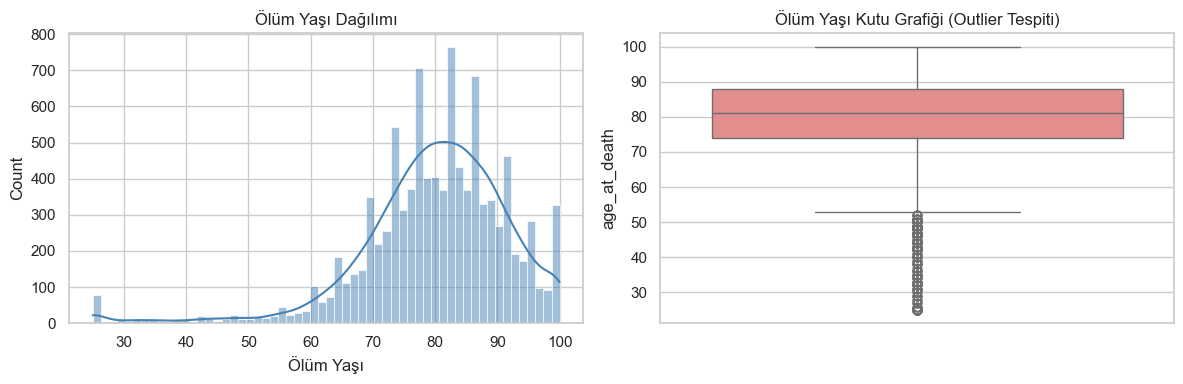

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
sns.histplot(df["age_at_death"], kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Ölüm Yaşı Dağılımı")
axes[0].set_xlabel("Ölüm Yaşı")
 
sns.boxplot(y=df["age_at_death"], color="lightcoral", ax=axes[1])
axes[1].set_title("Ölüm Yaşı Kutu Grafiği (Outlier Tespiti)")
 
plt.tight_layout()
plt.show()

## 📝 İki Değişkenli Analiz
---
### 3. Keşifsel Veri Analizi (Bivariate Analysis)
Meslek grupları ve cinsiyetin ölüm yaşı üzerindeki etkisini anlamak için Heatmap (Isı haritası) ve Boxplot (Kutu grafiği) kullanarak veriyi derinlemesine inceliyoruz.

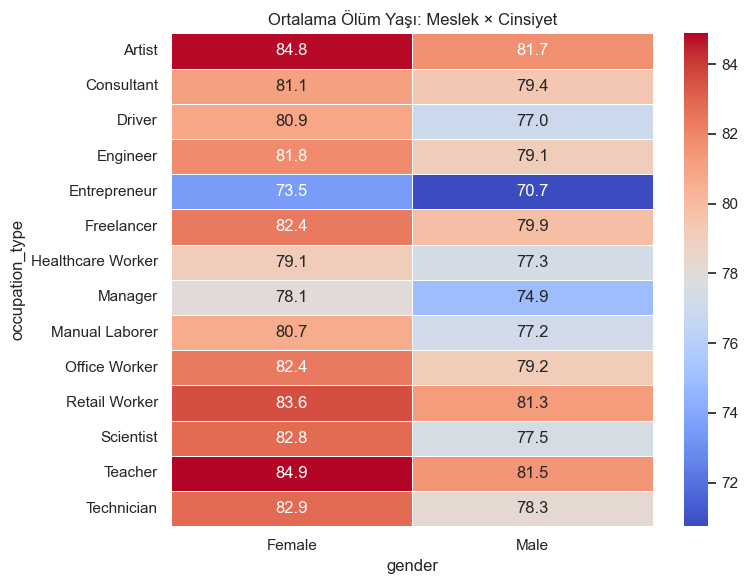

In [8]:
# Meslek x Cinsiyet Isı Haritası (Longevity Heatmap) 
pivot = df.pivot_table(
    values="age_at_death",
    index="occupation_type",
    columns="gender",
    aggfunc="mean",
)
 
plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="coolwarm", linewidths=0.5)
plt.title("Ortalama Ölüm Yaşı: Meslek × Cinsiyet")
plt.tight_layout()
plt.show()

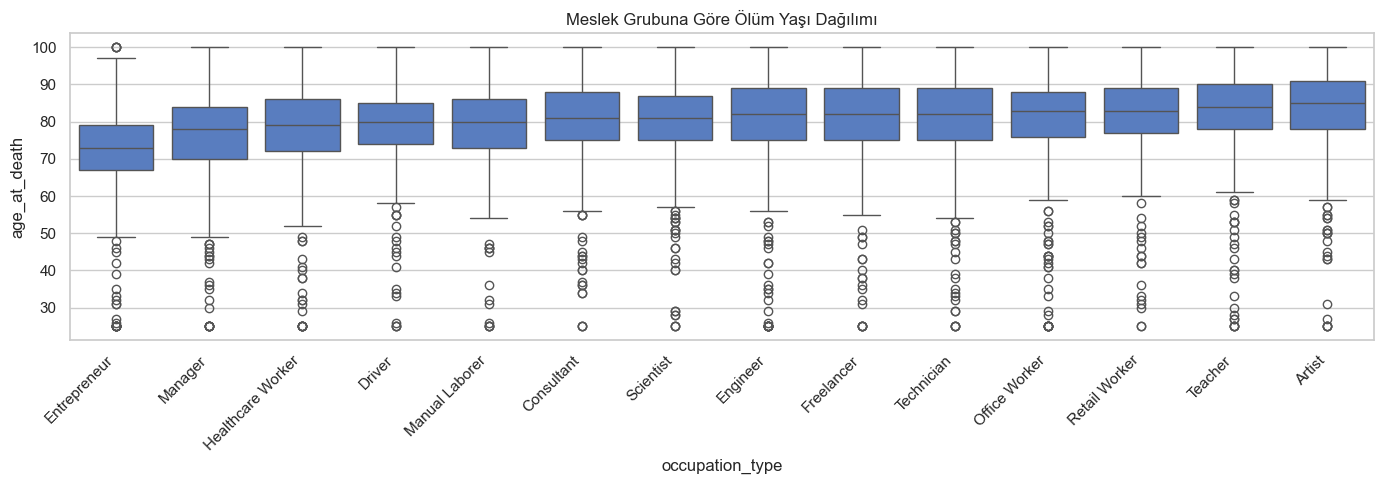

In [9]:
plt.figure(figsize=(14, 5))
order = df.groupby("occupation_type")["age_at_death"].median().sort_values().index
sns.boxplot(data=df, x="occupation_type", y="age_at_death", order=order)
plt.xticks(rotation=45, ha="right")
plt.title("Meslek Grubuna Göre Ölüm Yaşı Dağılımı")
plt.tight_layout()
plt.show()

## 📝 Aykırı Değer Yönetimi
---
### 4. Aykırı Değer (Outlier) Analizi ve Müdahalesi

**💡 Mühendislik Notu:** Clipping Stratejisi
Çeyrekler Açıklığı (IQR) yöntemi ile aykırı değerleri tespit ediyoruz. Eğer aykırı değerlerin oranı tüm veri setinin %5'inden az ise bunları veri setinden tamamen çıkarmak güvenlidir. Ancak %5'in üzerindeyse, veri kaybını (information loss) önlemek için Capping/Clipping (Baskılama) yöntemi kullanılır. Bu yöntem, aykırı değerleri alt ve üst sınırlara eşitler.

In [10]:
# IQR Hesaplama
Q1 = df["age_at_death"].quantile(0.25)
Q3 = df["age_at_death"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
 
# Aykırı Değer Tespiti
outlier_mask = (df["age_at_death"] < lower_bound) | (df["age_at_death"] > upper_bound)
outlier_count = outlier_mask.sum()
outlier_ratio = outlier_count / len(df)
 
print(f"📌 İstatistikler: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}")
print(f"🚧 Sınırlar: Alt Sınır: {lower_bound:.1f} | Üst Sınır: {upper_bound:.1f}")
print(f"🚨 Tespit Edilen Aykırı Değer: {outlier_count} adet (Toplam verinin %{outlier_ratio*100:.1f}'i)")

# Dinamik Müdahale Stratejisiif outlier_ratio < 0.05:
if outlier_ratio < 0.05:
    df = df[~outlier_mask].reset_index(drop=True)
    print("✅ Aksiyon: Aykırı değer oranı %5'in altında olduğu için satırlar silindi.")
else:
    df["age_at_death"] = df["age_at_death"].clip(lower_bound, upper_bound)
    print("✅ Aksiyon: Aykırı değer oranı yüksek olduğu için Clipping (Baskılama) uygulandı.")

📌 İstatistikler: Q1=74.0, Q3=88.0, IQR=14.0
🚧 Sınırlar: Alt Sınır: 53.0 | Üst Sınır: 109.0
🚨 Tespit Edilen Aykırı Değer: 278 adet (Toplam verinin %2.8'i)
✅ Aksiyon: Aykırı değer oranı %5'in altında olduğu için satırlar silindi.


---
## 📝 Veri Ön İşleme (Encoding)
---
### 5. Veri Dönüşümü (Encoding) ve Korelasyon Matrisi
Kategorik değişkenleri makine öğrenimi modellerinin anlayabileceği sayısal formatlara çeviriyoruz:

**1. Cinsiyet (Binary):** 0 ve 1 olarak haritalandı (Mapping).

**2. Meslek (Nominal):** One-Hot Encoding (pd.get_dummies) kullanıldı. Dummy Trap (Çoklu bağlantı sorunu) yaşamamak için drop_first=True parametresi uygulandı.

In [11]:
df['occupation_type'].value_counts()

occupation_type
Freelancer           760
Teacher              746
Office Worker        727
Scientist            720
Driver               711
Technician           704
Retail Worker        696
Consultant           693
Manager              692
Artist               672
Entrepreneur         666
Healthcare Worker    648
Manual Laborer       645
Engineer             642
Name: count, dtype: int64

In [12]:
df = pd.get_dummies(df, columns= ["occupation_type"], drop_first=True ,dtype=int)

In [13]:
df.head()

,gender,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death,occupation_type_Consultant,occupation_type_Driver,occupation_type_Engineer,occupation_type_Entrepreneur,occupation_type_Freelancer,occupation_type_Healthcare Worker,occupation_type_Manager,occupation_type_Manual Laborer,occupation_type_Office Worker,occupation_type_Retail Worker,occupation_type_Scientist,occupation_type_Teacher,occupation_type_Technician
0,Female,6.60,10.92,5.38,1.10,88,0,0,0,0,0,0,0,0,0,0,0,1,0
1,Male,9.65,7.65,6.31,0.39,76,0,0,0,0,0,0,0,0,1,0,0,0,0
2,Female,13.77,1.00,8.02,1.21,78,0,0,0,0,0,0,1,0,0,0,0,0,0
3,Female,10.94,5.18,7.59,0.29,74,0,0,0,0,1,0,0,0,0,0,0,0,0
4,Male,9.81,5.11,7.38,1.70,78,0,0,1,0,0,0,0,0,0,0,0,0,0


In [14]:
df['gender'] = df['gender'].map({"Female":0 , "Male":1})

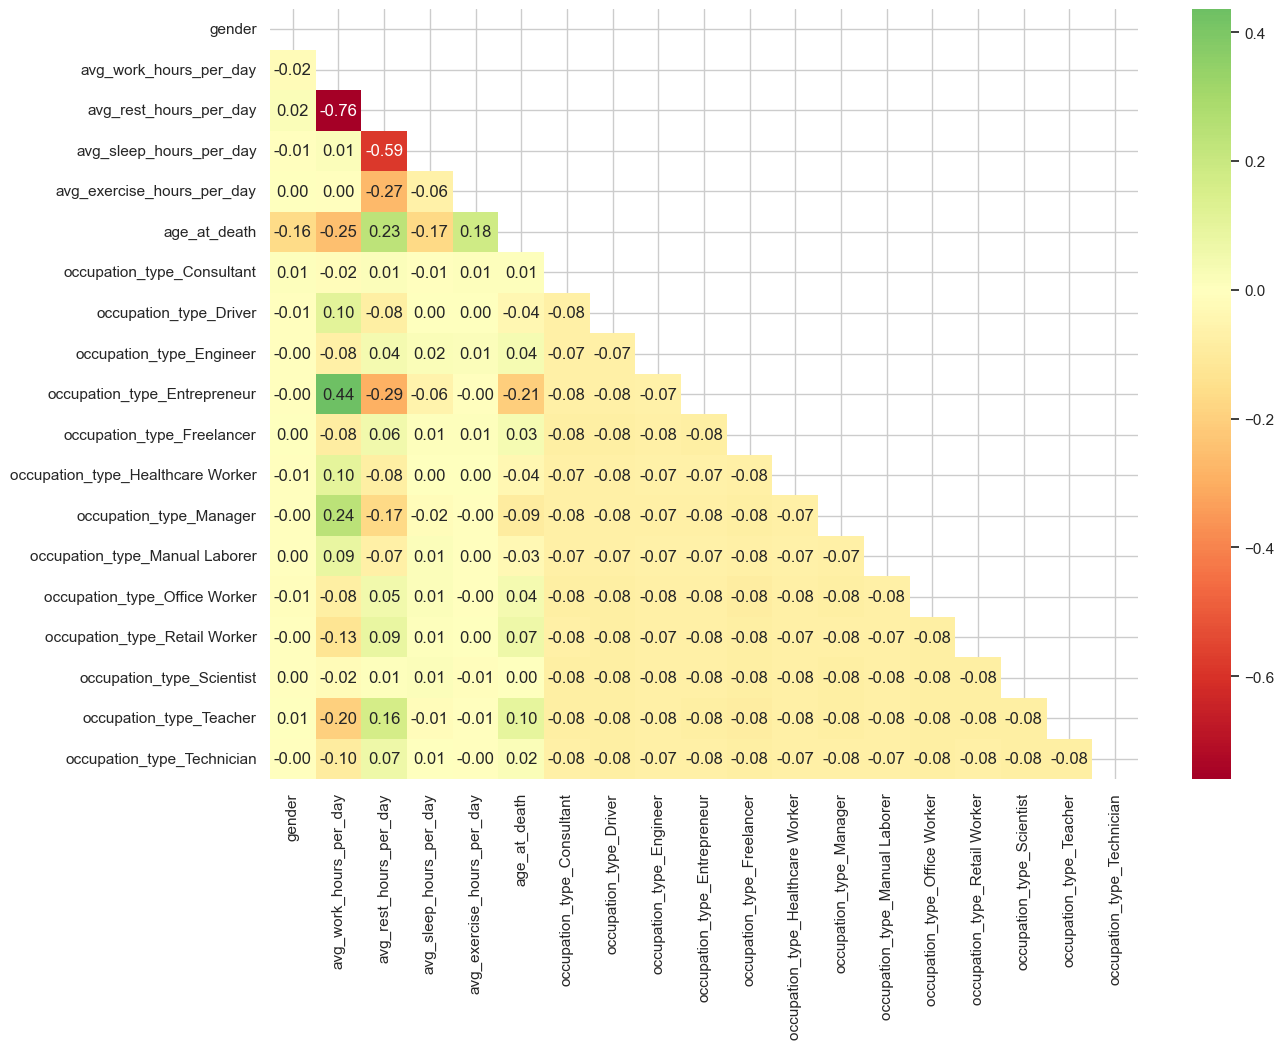

In [15]:
corr = df.corr()

mask = np.triu(np.ones_like(corr , dtype=bool))

plt.figure(figsize=(14,10))
sns.heatmap(data = corr , mask = mask , annot=True ,cmap = "RdYlGn",fmt = ".2f",center = 0 )
plt.show()

## 📝 Model Eğitim Hazırlığı
---
### 6. Veri Hazırlığı ve Ölçeklendirme (Standardization)
Regresyon modelleri (özellikle katsayı tabanlı cezalandırma yapan Ridge ve Lasso) değişkenlerin ölçeklerine karşı çok hassastır. Eğer veriyi standartlaştırmazsak, büyük sayılara sahip özellikler (örn. yıllık maaş) model tarafından yanlışlıkla daha önemli algılanabilir. Bu yüzden **StandardScaler** kullanarak veriyi ortalaması 0, standart sapması 1 olacak şekilde ($Z$-score) ölçeklendiriyoruz.

In [16]:
X = df.drop('age_at_death' , axis= 1)
y = df['age_at_death']

In [17]:
X_train , X_test , y_train , y_test = train_test_split(X, y, test_size = 0.2 , random_state = 42)

In [18]:
scaler = StandardScaler()

In [19]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 📝 Temel Regresyon Modelleri
---
### 7. Temel Modellerin Kurulması (Base Models)
Modelleri optimize etmeden önce varsayılan (default) parametrelerle nasıl performans gösterdiklerine bakıyoruz.
* **Ridge ($L2$):** Katsayıların karelerini küçülterek çoklu bağlantı (multicollinearity) sorununu çözer. Katsayıları tam sıfır yapmaz.
* **Lasso ($L1$):** Katsayıların mutlak değerlerini küçültür. Önemsiz değişkenlerin katsayısını 0 yaparak Feature Selection (Özellik Seçimi) görevi görür.
* **ElasticNet ($L1+L2$):** Ridge ve Lasso'nun birleşimidir. İki ceza türünü oranlayarak uygular.

In [20]:
model = Ridge()

In [21]:
model.fit(X_train_scaled , y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [22]:
y_pred = model.predict(X_test_scaled)

In [23]:
print("=" * 40)
print("R2 Score : ", r2_score(y_test , y_pred)) 
print("=" * 40)
print("Mean Squared Error :\n",mean_squared_error(y_test , y_pred))
print("=" * 40)
print("Mean Absolue Error:\n",mean_absolute_error(y_test , y_pred))
print("=" * 40)

R2 Score :  0.16408186729694996
Mean Squared Error :
 77.20715651726287
Mean Absolue Error:
 6.900165335648521


In [24]:
model_lasso = Lasso()

In [25]:
model_lasso.fit(X_train_scaled , y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [26]:
y_pred = model_lasso.predict(X_test_scaled)

In [27]:
print("=" * 40)
print("R2 Score : ", r2_score(y_test , y_pred)) 
print("=" * 40)
print("Mean Squared Error :\n",mean_squared_error(y_test , y_pred))
print("=" * 40)
print("Mean Absolue Error:\n",mean_absolute_error(y_test , y_pred))
print("=" * 40)

R2 Score :  0.10734367631834452
Mean Squared Error :
 82.4476151459402
Mean Absolue Error:
 7.188757332496808


In [28]:
model_elasticnet = ElasticNet()

In [29]:
model_elasticnet.fit(X_train_scaled , y_train)

,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [30]:
y_pred = model_elasticnet.predict(X_test_scaled)

In [31]:
print("=" * 40)
print("R2 Score : ", r2_score(y_test , y_pred)) 
print("=" * 40)
print("Mean Squared Error :\n",mean_squared_error(y_test , y_pred))
print("=" * 40)
print("Mean Absolue Error:\n",mean_absolute_error(y_test , y_pred))
print("=" * 40)

R2 Score :  0.11904954143920055
Mean Squared Error :
 81.36643682811449
Mean Absolue Error:
 7.1344803660724745


## 📝 Hiperparametre Optimizasyonu
---
### 8. Hiperparametre Optimizasyonu (GridSearchCV)
Modellerin performansını artırmak için ceza parametrelerini ($\alpha$) test ediyoruz. Lasso için iterasyon sayısını artırarak **(max_iter=10000)** modelin karmaşık verilerde yakınsamasına (convergence) yardımcı oluyoruz.

In [32]:
# Raporlama işlemini temiz ve okunabilir yapmak için yardımcı fonksiyonumuz
def evaluate_best_model(model_name, grid_model, X_test, y_test):
    y_pred = grid_model.predict(X_test)
    print(f"=== {model_name} (Optimize Edilmiş) ===")
    print(f"Bulunan En İyi Parametreler : {grid_model.best_params_}")
    print(f"Yeni R2 Score               : {r2_score(y_test, y_pred):.4f}")
    print(f"Yeni Mean Squared Error     : {mean_squared_error(y_test, y_pred):.4f}")
    print(f"Yeni Mean Absolute Error    : {mean_absolute_error(y_test, y_pred):.4f}")
    print("-" * 50)

# ==========================================
# 1. RIDGE İÇİN GRID SEARCH
# ==========================================
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]}

# cv=5 ile veriyi 5'e katlayarak test ediyoruz
grid_ridge = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
grid_ridge.fit(X_train_scaled, y_train)

evaluate_best_model("Ridge Regresyon", grid_ridge, X_test_scaled, y_test)

# ==========================================
# 2. LASSO İÇİN GRID SEARCH
# ==========================================
# Lasso çok sert cezalandırır, bu yüzden küçük alpha değerleri de ekledik
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}

grid_lasso = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring='r2')
grid_lasso.fit(X_train_scaled, y_train)

evaluate_best_model("Lasso Regresyon", grid_lasso, X_test_scaled, y_test)

# ==========================================
# 3. ELASTICNET İÇİN GRID SEARCH
# ==========================================
elasticnet_params = {
    'alpha': [0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.99] 
}

grid_elasticnet = GridSearchCV(ElasticNet(max_iter=10000), elasticnet_params, cv=5, scoring='r2')
grid_elasticnet.fit(X_train_scaled, y_train)

evaluate_best_model("ElasticNet Regresyon", grid_elasticnet, X_test_scaled, y_test)

=== Ridge Regresyon (Optimize Edilmiş) ===
Bulunan En İyi Parametreler : {'alpha': 0.01}
Yeni R2 Score               : 0.1654
Yeni Mean Squared Error     : 77.0873
Yeni Mean Absolute Error    : 6.9003
--------------------------------------------------
=== Lasso Regresyon (Optimize Edilmiş) ===
Bulunan En İyi Parametreler : {'alpha': 0.001}
Yeni R2 Score               : 0.1639
Yeni Mean Squared Error     : 77.2246
Yeni Mean Absolute Error    : 6.9003
--------------------------------------------------
=== ElasticNet Regresyon (Optimize Edilmiş) ===
Bulunan En İyi Parametreler : {'alpha': 0.01, 'l1_ratio': 0.1}
Yeni R2 Score               : 0.1634
Yeni Mean Squared Error     : 77.2732
Yeni Mean Absolute Error    : 6.9006
--------------------------------------------------


In [33]:
# 1. CV skoru göster
print(f"CV R² (train): {grid_ridge.best_score_:.4f}")
print(f"Test R²:       {r2_score(y_test, grid_ridge.predict(X_test_scaled)):.4f}")
# Fark büyükse: overfitting. Küçükse ve ikisi de düşükse: underfitting.

CV R² (train): 0.1739
Test R²:       0.1654


Text(0.5, 1.0, 'Residual Plot')

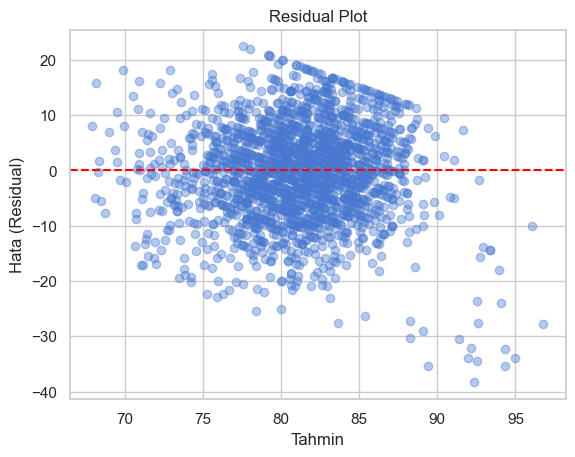

In [34]:
# 2. Residual plot — en temel tanı aracı
y_pred = grid_ridge.predict(X_test_scaled)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Tahmin"); plt.ylabel("Hata (Residual)")
plt.title("Residual Plot")